# Avance del Proyecto — Fases 2 y 3

## Exploración inteligente para la Ciencia de Datos (MCDI503)

**Título del avance:** Diagnóstico de calidad, limpieza, integración, transformación y análisis exploratorio univariado-bivariado del dataset Titanic — Fases 2 y 3

**Integrantes del equipo (Grupo 5):**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Dataset(s) utilizado(s):**
- **Fuente principal:** `Titanic-Dataset.csv` (891 registros, 12 variables), Kaggle — *Titanic: Machine Learning from Disaster*. Es el mismo dataset trabajado en la Fase 1.
- **Fuente complementaria (integración, origen web):** `titanic` de la librería `seaborn` (repositorio público `mwaskom/seaborn-data`, mismo universo de pasajeros del Titanic re-codificado con variables adicionales: `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`). Se utiliza en la Fase 2 para el ejercicio de integración de datos exigido por la pauta (ID2.3). El archivo se descargó una única vez (`seaborn.load_dataset("titanic")`) y se guardó en `data/titanic_seaborn_reference.csv` para asegurar que el notebook sea ejecutable de forma reproducible sin depender de conexión a internet en el momento de la evaluación.

**Propósito general del notebook:** Documentar, de forma reproducible y trazable, el ciclo completo exigido para las Fases 2 y 3 del proyecto: (a) diagnóstico técnico del estado de calidad de los datos, (b) limpieza, validación e integración de una fuente complementaria, (c) transformación y preparación analítica del dataset, y (d) desarrollo de un análisis exploratorio univariado y bivariado que permita identificar patrones, relaciones y anomalías relevantes para la comprensión del problema (supervivencia de pasajeros del Titanic), como continuación directa del avance formativo de la Fase 1.

---
## II. Carga del dataset y descripción inicial

Se importan las librerías necesarias (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`) y se cargan ambas fuentes de datos: el dataset principal (`Titanic-Dataset.csv`) y la fuente complementaria cacheada (`titanic_seaborn_reference.csv`), utilizada más adelante para el ejercicio de integración. Se revisa la estructura básica (dimensiones, primeras filas) de ambas fuentes.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
RUTA_DATOS = "../data/Titanic-Dataset.csv"
RUTA_DATOS_WEB = "../data/titanic_seaborn_reference.csv"
RUTA_FIGURAS = "../figures"
RUTA_SALIDA = "../data/titanic_prepared.csv"

titanic = pd.read_csv(RUTA_DATOS)
print("Fuente principal — dimensiones:", titanic.shape)
titanic.head()

Fuente principal — dimensiones: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Fuente complementaria (origen web): seaborn-data "titanic" (mwaskom/seaborn-data)
# Descarga original (ejecutada una sola vez, fuera de este notebook, para fijar una copia reproducible):
#   titanic_web = sns.load_dataset("titanic")
#   titanic_web.to_csv("../data/titanic_seaborn_reference.csv", index=False)
titanic_web = pd.read_csv(RUTA_DATOS_WEB)
print("Fuente complementaria (web) — dimensiones:", titanic_web.shape)
titanic_web.head()

Fuente complementaria (web) — dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Descripción inicial:** la fuente principal tiene 891 filas y 12 columnas; la fuente complementaria tiene 891 filas y 15 columnas. Ambas describen, en principio, al mismo universo de pasajeros del Titanic, pero **no comparten un identificador explícito común** (la fuente web no incluye `PassengerId` ni `Name`), por lo que la validez de una eventual integración debe demostrarse antes de combinarlas (apartado V).

---
## III. Revisión del contenido del dataset

Se inspeccionan los tipos de datos, los nombres de los campos y la estructura general de ambas fuentes, como base para el diagnóstico de calidad del apartado siguiente.

In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
titanic_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


**Observaciones generales sobre la estructura:**

- La fuente principal contiene variables numéricas continuas (`Age`, `Fare`), numéricas discretas (`SibSp`, `Parch`, `Pclass`, `Survived` binaria) y de texto/categóricas (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`). `PassengerId` es un identificador único sin valor analítico directo.
- La fuente complementaria re-codifica varias de estas mismas variables (`pclass`→`class` como etiqueta ordinal, `sex`/`age`→`who`/`adult_male` como variables derivadas, `embarked`→`embark_town` como nombre de puerto, `cabin`→`deck` como letra de cubierta) y agrega `alive` (redundante con `survived`) y `alone` (equivalente a un indicador de viajar solo).
- A simple vista, `Age`/`age`, `Cabin`/`deck` y `Embarked`/`embark_town` muestran menos registros no nulos que el total de filas en ambas fuentes, lo que anticipa valores faltantes que se cuantifican en el apartado IV.
- La correspondencia conceptual entre variables de ambas fuentes (mismo significado, distinta codificación) es justamente lo que se debe validar semánticamente antes de integrarlas.

---
## IV. Diagnóstico de calidad de datos

Se cuantifican valores faltantes, se revisan duplicados y se identifican inconsistencias o categorías problemáticas en la fuente principal, insumo directo para las decisiones de limpieza del apartado V.

In [5]:
faltantes = titanic.isna().sum().sort_values(ascending=False)
porcentaje = (titanic.isna().mean() * 100).round(2).sort_values(ascending=False)
resumen_faltantes = pd.DataFrame({"n_faltantes": faltantes, "pct_faltantes": porcentaje})
resumen_faltantes = resumen_faltantes[resumen_faltantes["n_faltantes"] > 0]
resumen_faltantes

,n_faltantes,pct_faltantes
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [6]:
# Duplicados
n_filas_duplicadas = titanic.duplicated().sum()
n_passenger_id_duplicados = titanic["PassengerId"].duplicated().sum()
n_tickets_repetidos = titanic["Ticket"].duplicated().sum()

print("Filas exactamente duplicadas:", n_filas_duplicadas)
print("PassengerId duplicados (debe ser único):", n_passenger_id_duplicados)
print("Tickets que se repiten (posibles grupos familiares/compañeros de viaje):", n_tickets_repetidos)

Filas exactamente duplicadas: 0
PassengerId duplicados (debe ser único): 0
Tickets que se repiten (posibles grupos familiares/compañeros de viaje): 210


In [7]:
# Inconsistencias y rangos válidos
inconsistencias = {
    "Sex fuera de {male, female}": (~titanic["Sex"].isin(["male", "female"])).sum(),
    "Embarked fuera de {S, C, Q, NaN}": (~titanic["Embarked"].isin(["S", "C", "Q"]) & titanic["Embarked"].notna()).sum(),
    "Pclass fuera de {1, 2, 3}": (~titanic["Pclass"].isin([1, 2, 3])).sum(),
    "Survived fuera de {0, 1}": (~titanic["Survived"].isin([0, 1])).sum(),
    "Age <= 0 o Age > 100": (((titanic["Age"] <= 0) | (titanic["Age"] > 100)) & titanic["Age"].notna()).sum(),
    "Fare < 0": (titanic["Fare"] < 0).sum(),
    "Fare == 0": (titanic["Fare"] == 0).sum(),
}
pd.Series(inconsistencias, name="n_casos")

Sex fuera de {male, female}          0
Embarked fuera de {S, C, Q, NaN}     0
Pclass fuera de {1, 2, 3}            0
Survived fuera de {0, 1}             0
Age <= 0 o Age > 100                 0
Fare < 0                             0
Fare == 0                           15
Name: n_casos, dtype: int64

In [8]:
# Categorías/campos con formato problemático
n_cabin_multiple = titanic["Cabin"].dropna().str.split().apply(len).gt(1).sum()
print(f"Registros con más de un camarote listado en 'Cabin': {n_cabin_multiple} de {titanic['Cabin'].notna().sum()} no nulos")

# Evidencia de asociación entre Cabin no registrada y Pclass (apoya la hipótesis de MNAR/estructural, no error aleatorio)
cabin_por_clase = pd.crosstab(titanic["Pclass"], titanic["Cabin"].isna(), normalize="index").round(3) * 100
cabin_por_clase.columns = ["Cabin_registrada_%", "Cabin_faltante_%"]
cabin_por_clase

Registros con más de un camarote listado en 'Cabin': 24 de 204 no nulos


,Cabin_registrada_%,Cabin_faltante_%
Pclass,,
1,81.5,18.5
2,8.7,91.3
3,2.4,97.6


**Diagnóstico de calidad de datos — síntesis:**

- **Valores faltantes:** `Cabin` (687; 77.1%), `Age` (177; 19.9%) y `Embarked` (2; 0.22%). El resto de las variables no presenta valores faltantes.
- **Duplicados:** no se detectan filas exactamente duplicadas ni `PassengerId` repetidos (el identificador es efectivamente único, tal como se asume en el diseño del dataset). Sí existen 210 valores de `Ticket` que se repiten, lo que **no constituye un error** sino evidencia de pasajeros que compartieron un mismo boleto (grupos familiares o acompañantes), información relevante para interpretar outliers de `Fare` más adelante (apartado IX).
- **Inconsistencias de rango/dominio:** no se detectan valores fuera de dominio en `Sex`, `Embarked`, `Pclass`, `Survived` ni edades fuera de un rango plausible (0–100 años). Se detectan 15 registros con `Fare == 0`, un valor plausible en el contexto histórico (boletos de cortesía o tripulación/empleados registrados como pasajeros), pero que se marca como caso a vigilar por su potencial impacto en el análisis de `Fare`.
- **Formato de `Cabin`:** una parte de los registros no nulos de `Cabin` (multi-valor) lista más de un camarote (p. ej., `"C23 C25 C27"`), lo que exige una decisión explícita de extracción (se usa la primera letra como proxy de cubierta en el apartado V/VI).
- **Campos críticos identificados para la preparación:** `Age` (proporción relevante de faltantes, tratamiento cuidadoso), `Cabin` (faltante mayoritario, no imputable de forma confiable), `Embarked` (impacto marginal, imputación puntual justificable) y `Fare` (asimetría y presencia de outliers, ver apartado IX).
- La tabla de `Cabin` faltante por `Pclass` muestra que la proporción de camarote registrado decrece fuertemente con la clase (mayor registro en 1ª clase, prácticamente nulo en 3ª), lo que sugiere que la ausencia de `Cabin` **no es aleatoria** sino estructural (asociada a la clase de pasaje) y refuerza la decisión de no imputar su valor específico.

---
## V. Limpieza, validación e integración

Se aplican las decisiones de limpieza y validación sobre la fuente principal y se desarrolla el ejercicio de **integración** con la fuente complementaria (origen web), documentando el criterio utilizado para validar la correspondencia entre registros dado que no existe una llave explícita común.

### V.1 Limpieza y validación de la fuente principal

In [9]:
titanic_clean = titanic.copy()

# (a) Duplicados: no se detectaron filas duplicadas (apartado IV); se documenta el criterio igualmente
titanic_clean = titanic_clean.drop_duplicates()
assert titanic_clean["PassengerId"].is_unique, "PassengerId debería ser único"

# (b) Embarked: imputación puntual definitiva con la moda (2 casos, 0.22% del total)
moda_embarked = titanic_clean["Embarked"].mode(dropna=True).iloc[0]
titanic_clean["Embarked_clean"] = titanic_clean["Embarked"].fillna(moda_embarked)
print(f"Embarked: {titanic_clean['Embarked'].isna().sum()} valores faltantes imputados con la moda ('{moda_embarked}')")

Embarked: 2 valores faltantes imputados con la moda ('S')


In [10]:
# (c) Age: imputación definitiva estratificada por Pclass x Sex (más precisa que una única mediana global)
# Validación estadística de que la estratificación es pertinente: ¿difiere Age entre los grupos Pclass x Sex?
grupos_edad = [g["Age"].dropna().values for _, g in titanic_clean.groupby(["Pclass", "Sex"]) if g["Age"].notna().sum() > 0]
h_stat, p_valor_kw = stats.kruskal(*grupos_edad)
print(f"Kruskal-Wallis Age ~ Pclass x Sex: H={h_stat:.2f}, p-valor={p_valor_kw:.2e}")

titanic_clean["Age_registrada"] = titanic_clean["Age"].notna().astype(int)
mediana_edad_grupo = titanic_clean.groupby(["Pclass", "Sex"])["Age"].transform("median")
mediana_global = titanic_clean["Age"].median()
titanic_clean["Age_clean"] = titanic_clean["Age"].fillna(mediana_edad_grupo).fillna(mediana_global)

print(f"\nAge: {titanic_clean['Age'].isna().sum()} valores faltantes imputados con la mediana de su grupo Pclass x Sex")
print("Mediana de Age por Pclass x Sex (referencia de imputación):")
titanic_clean.groupby(["Pclass", "Sex"])["Age"].median().round(1)

Kruskal-Wallis Age ~ Pclass x Sex: H=112.28, p-valor=1.35e-22

Age: 177 valores faltantes imputados con la mediana de su grupo Pclass x Sex
Mediana de Age por Pclass x Sex (referencia de imputación):


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

El test de Kruskal-Wallis (no paramétrico, apropiado dado que `Age` no se distribuye normalmente dentro de cada grupo — se confirma formalmente en el apartado VII) indica diferencias significativas de edad entre los grupos `Pclass × Sex` (p < 0.001). Esto **justifica estadísticamente** imputar `Age` con la mediana estratificada por `Pclass` y `Sex`, en lugar de una única mediana global, ya que esta última subestimaría o sobrestimaría sistemáticamente la edad en varios subgrupos. Se conserva `Age_registrada` como indicador de que el valor fue observado (1) o imputado (0), preservando la señal de "missingness" para un eventual uso analítico posterior.

In [11]:
# (d) Cabin: no se imputa el camarote específico (77.1% de faltantes, ver apartado IV); se conserva un indicador
titanic_clean["Cabin_registrada"] = titanic_clean["Cabin"].notna().astype(int)
titanic_clean["Cabin_letra"] = titanic_clean["Cabin"].str[0]
print("Letras de cubierta detectadas en 'Cabin' (fuente principal):", sorted(titanic_clean["Cabin_letra"].dropna().unique()))

Letras de cubierta detectadas en 'Cabin' (fuente principal): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']


### V.2 Integración con la fuente complementaria (origen web)

La fuente complementaria (`seaborn`-data) no comparte un identificador con la fuente principal. Antes de integrarla es necesario **validar la correspondencia registro a registro**, comprobando si ambas fuentes están ordenadas de manera idéntica a partir de las variables que sí son conceptualmente equivalentes entre ambas (`Pclass`/`pclass`, `Sex`/`sex`, `Age`/`age`, `SibSp`/`sibsp`, `Parch`/`parch`, `Fare`/`fare`, `Survived`/`survived`).

In [12]:
# Validación de alineación registro a registro entre ambas fuentes (no existe llave explícita común)
comparaciones = {
    "Pclass == pclass": (titanic["Pclass"].values == titanic_web["pclass"].values).mean(),
    "Sex == sex": (titanic["Sex"].values == titanic_web["sex"].values).mean(),
    "SibSp == sibsp": (titanic["SibSp"].values == titanic_web["sibsp"].values).mean(),
    "Parch == parch": (titanic["Parch"].values == titanic_web["parch"].values).mean(),
    "Survived == survived": (titanic["Survived"].values == titanic_web["survived"].values).mean(),
    "Fare == fare": np.isclose(titanic["Fare"].values, titanic_web["fare"].values, atol=1e-3).mean(),
    "Age == age (incl. NaN==NaN)": np.equal(
        np.isnan(titanic["Age"].values), np.isnan(titanic_web["age"].values)
    ).mean() * np.isclose(
        titanic["Age"].fillna(-1).values, titanic_web["age"].fillna(-1).values, atol=1e-6
    ).mean(),
}
validacion_llave = pd.Series(comparaciones, name="pct_coincidencia")
validacion_llave

Pclass == pclass               1.0
Sex == sex                     1.0
SibSp == sibsp                 1.0
Parch == parch                 1.0
Survived == survived           1.0
Fare == fare                   1.0
Age == age (incl. NaN==NaN)    1.0
Name: pct_coincidencia, dtype: float64

La coincidencia es del 100% en las siete variables comparadas, lo que constituye evidencia suficiente de que ambas fuentes están ordenadas de forma idéntica y corresponden fila a fila al mismo pasajero. Esta validación reemplaza, en ausencia de una llave explícita, a la revisión de claves habitual en un merge por identificador, y es la que **habilita técnicamente** la integración por posición (índice). Se documenta como supuesto y limitación en el apartado X: si cualquiera de las dos fuentes cambiara su orden interno, esta integración dejaría de ser válida y debería rehacerse por otro método (p. ej., *matching* aproximado por nombre).

In [13]:
# Integración: se incorporan las variables no presentes en la fuente principal
columnas_a_integrar = ["class", "who", "adult_male", "deck", "embark_town", "alone"]
titanic_int = titanic_clean.reset_index(drop=True).join(titanic_web[columnas_a_integrar].reset_index(drop=True))
print("Dimensiones tras la integración:", titanic_int.shape)
titanic_int[["Pclass", "class", "Sex", "who", "Embarked_clean", "embark_town", "Cabin_letra", "deck"]].head(6)

Dimensiones tras la integración: (891, 23)


,Pclass,class,Sex,who,Embarked_clean,embark_town,Cabin_letra,deck
0,3,Third,male,man,S,Southampton,NaN,NaN
1,1,First,female,woman,C,Cherbourg,C,C
2,3,Third,female,woman,S,Southampton,NaN,NaN
3,1,First,female,woman,S,Southampton,C,C
4,3,Third,male,man,S,Southampton,NaN,NaN
5,3,Third,male,man,Q,Queenstown,NaN,NaN


In [14]:
# Coherencia semántica de la integración: variables conceptualmente equivalentes deben coincidir
coherencia_embarked = pd.crosstab(titanic_int["Embarked_clean"], titanic_int["embark_town"])
coherencia_clase = pd.crosstab(titanic_int["Pclass"], titanic_int["class"])

deck_comparable = titanic_int.dropna(subset=["Cabin_letra", "deck"])
pct_coherencia_deck = (deck_comparable["Cabin_letra"] == deck_comparable["deck"]).mean() * 100

print("Coherencia Embarked_clean vs embark_town:\n", coherencia_embarked, "\n")
print("Coherencia Pclass vs class:\n", coherencia_clase, "\n")
print(f"Coherencia Cabin_letra vs deck (sobre {len(deck_comparable)} casos con ambos valores presentes): {pct_coherencia_deck:.1f}%")

Coherencia Embarked_clean vs embark_town:
 embark_town     Cherbourg  Queenstown  Southampton
Embarked_clean                                    
C                     168           0            0
Q                       0          77            0
S                       0           0          644 

Coherencia Pclass vs class:
 class   First  Second  Third
Pclass                      
1         216       0      0
2           0     184      0
3           0       0    491 

Coherencia Cabin_letra vs deck (sobre 203 casos con ambos valores presentes): 100.0%


**Validación de coherencia estructural y semántica de la integración:**

- `Embarked_clean` vs. `embark_town`: correspondencia perfecta y diagonal (S↔Southampton, C↔Cherbourg, Q↔Queenstown), confirmando que ambas variables codifican el mismo concepto sin ambigüedad.
- `Pclass` vs. `class`: correspondencia perfecta y diagonal (1↔First, 2↔Second, 3↔Third).
- `Cabin_letra` (primera letra de `Cabin`, fuente principal) vs. `deck` (fuente complementaria): coinciden en el 100% de los casos en que ambas variables están disponibles simultáneamente, lo que confirma que describen el mismo atributo (cubierta del camarote) con la misma codificación de letras. La cobertura conjunta sigue siendo baja (ambas fuentes heredan el mismo 77% de faltantes en el dato de camarote), por lo que la integración **no resuelve** el problema de calidad de `Cabin` diagnosticado en el apartado IV, pero sí aporta una variable adicional (`deck`) idéntica en su parte observada, que se usa como respaldo/completitud menor en el apartado VI.
- En síntesis, la integración se valida como **estructuralmente coherente** (mismo número de filas, mismo orden) y **semánticamente coherente** (las variables conceptualmente equivalentes coinciden en el 100% de los casos comparables).

---
## VI. Transformaciones aplicadas y preparación del dataset

Se aplican transformaciones de variables orientadas a dejar el dataset listo para el análisis exploratorio univariado y bivariado (apartados VII-IX), documentando el sentido analítico de cada una.

In [15]:
df = titanic_int.copy()

# (1) Sex a formato binario numérico, conservando la versión categórica
df["Sex_bin"] = df["Sex"].map({"male": 0, "female": 1})

# (2) Título extraído del nombre, agrupado en categorías con criterio sociodemográfico explícito
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()

mapa_titulos = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Dr": "Oficial_Profesional", "Rev": "Oficial_Profesional", "Col": "Oficial_Profesional",
    "Major": "Oficial_Profesional", "Capt": "Oficial_Profesional",
    "Lady": "Nobleza", "the Countess": "Nobleza", "Sir": "Nobleza",
    "Jonkheer": "Nobleza", "Don": "Nobleza", "Dona": "Nobleza",
}
df["Title_agrupado"] = df["Title"].replace(mapa_titulos)
df.loc[~df["Title_agrupado"].isin(["Mr", "Mrs", "Miss", "Master", "Oficial_Profesional", "Nobleza"]), "Title_agrupado"] = "Otro"

df["Title_agrupado"].value_counts()

Title_agrupado
Mr                     517
Miss                   185
Mrs                    126
Master                  40
Oficial_Profesional     18
Nobleza                  5
Name: count, dtype: int64

In [16]:
# (3) Variables de composición familiar
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# (4) Agrupación etaria (rangos con sentido demográfico, sobre Age_clean ya imputada)
bins_edad = [0, 12, 17, 35, 60, np.inf]
etiquetas_edad = ["Niño (0-12)", "Adolescente (13-17)", "Adulto joven (18-35)", "Adulto (36-60)", "Mayor (60+)"]
df["AgeGroup"] = pd.cut(df["Age_clean"], bins=bins_edad, labels=etiquetas_edad, right=True)

# (5) Fare: transformación logarítmica (reduce asimetría) y agrupación en cuartiles
asimetria_fare = stats.skew(df["Fare"])
df["Fare_log"] = np.log1p(df["Fare"])
asimetria_fare_log = stats.skew(df["Fare_log"])
df["FareBand"] = pd.qcut(df["Fare"], q=4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])

print(f"Asimetría de Fare: {asimetria_fare:.2f}  ->  Asimetría de Fare_log (log1p): {asimetria_fare_log:.2f}")

Asimetría de Fare: 4.78  ->  Asimetría de Fare_log (log1p): 0.39


In [17]:
# (6) Camarote combinado: se completa Cabin_letra con deck cuando la fuente principal no tiene el dato
#     pero la complementaria sí (dado que se validó su coherencia del 100% en el apartado V)
df["Deck_combinado"] = df["Cabin_letra"].fillna(df["deck"]).astype("object").fillna("Desconocida")
df["Deck_combinado"].value_counts()

Deck_combinado
Desconocida    687
C               59
B               47
D               33
E               32
A               15
F               13
G                4
T                1
Name: count, dtype: int64

In [18]:
# (7) Ajuste de tipos: variables nominales/ordinales a dtype 'category'
# Nota: 'Survived' se mantiene como entero (0/1) y no se castea a 'category', ya que se usa
# repetidamente en agregaciones numericas (medias = tasas de supervivencia); convertirla a
# categorica invierte el orden esperado en algunas agregaciones de seaborn.
columnas_categoricas = ["Pclass", "Sex", "Embarked_clean", "Title_agrupado",
                         "AgeGroup", "FareBand", "Deck_combinado", "IsAlone"]
for c in columnas_categoricas:
    df[c] = df[c].astype("category")

print("Preparación final del dataset:", df.shape)
df.dtypes.value_counts()

Preparación final del dataset: (891, 32)


str         10
int64        8
float64      4
bool         2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [19]:
df.to_csv(RUTA_SALIDA, index=False)
print(f"Dataset preparado exportado a {RUTA_SALIDA}")
df[["PassengerId", "Survived", "Pclass", "Sex", "Age_clean", "Age_registrada", "Fare", "Fare_log",
    "FamilySize", "IsAlone", "Title_agrupado", "AgeGroup", "Deck_combinado", "Embarked_clean"]].head(8)

Dataset preparado exportado a ../data/titanic_prepared.csv


,PassengerId,Survived,Pclass,Sex,Age_clean,Age_registrada,Fare,Fare_log,FamilySize,IsAlone,Title_agrupado,AgeGroup,Deck_combinado,Embarked_clean
0,1,0,3,male,22.0,1,7.2500,2.110213,2,0,Mr,Adulto joven (18-35),Desconocida,S
1,2,1,1,female,38.0,1,71.2833,4.280593,2,0,Mrs,Adulto (36-60),C,C
2,3,1,3,female,26.0,1,7.9250,2.188856,1,1,Miss,Adulto joven (18-35),Desconocida,S
3,4,1,1,female,35.0,1,53.1000,3.990834,2,0,Mrs,Adulto joven (18-35),C,S
4,5,0,3,male,35.0,1,8.0500,2.202765,1,1,Mr,Adulto joven (18-35),Desconocida,S
5,6,0,3,male,25.0,0,8.4583,2.246893,1,1,Mr,Adulto joven (18-35),Desconocida,Q
6,7,0,1,male,54.0,1,51.8625,3.967694,1,1,Mr,Adulto (36-60),E,S
7,8,0,3,male,2.0,1,21.0750,3.094446,5,0,Master,Niño (0-12),Desconocida,S


**Sentido analítico de las transformaciones:** `Sex_bin` y las variables `category` habilitan su uso directo en pruebas estadísticas y en modelado futuro. `Title_agrupado` condensa sexo, edad aproximada y estatus social en seis categorías interpretables, con un criterio explícito de agrupación (no una bolsa residual arbitraria). `FamilySize`/`IsAlone` capturan la composición familiar más allá de `SibSp`/`Parch` por separado. `AgeGroup` permite un análisis bivariado categórico de `Age_clean` sin asumir linealidad. La transformación logarítmica de `Fare` reduce sustancialmente su fuerte asimetría positiva (coeficiente de asimetría reportado en la salida anterior), lo que es relevante porque varias visualizaciones univariadas se benefician de una escala menos comprimida en los valores bajos; `FareBand` ofrece, en paralelo, una lectura categórica robusta a la escala. `Deck_combinado` aprovecha la integración de la Sección V para maximizar la información disponible sobre cubierta sin alterar el diagnóstico de fondo (la mayoría de los casos permanece como `"Desconocida"`).

---
## VII. Análisis univariado

Se examinan las distribuciones de las variables numéricas y categóricas priorizadas para el proyecto, combinando estadísticas descriptivas (con evaluación formal de normalidad, para decidir entre medidas clásicas o robustas) y visualizaciones adecuadas a la forma de cada distribución.

In [20]:
def diagnostico_normalidad(serie, nombre):
    datos = serie.dropna()
    est, p = stats.normaltest(datos)  # D'Agostino-Pearson K^2, apropiado para n grande
    return {
        "variable": nombre, "n": len(datos),
        "media": round(datos.mean(), 2), "mediana": round(datos.median(), 2), "sd": round(datos.std(), 2),
        "IQR": round(datos.quantile(0.75) - datos.quantile(0.25), 2),
        "asimetria": round(stats.skew(datos), 2), "curtosis_exceso": round(stats.kurtosis(datos), 2),
        "normaltest_stat": round(est, 2), "normaltest_p": p,
        "es_normal_(alpha=.05)": p > 0.05,
    }

variables_numericas_prioritarias = ["Age_clean", "Fare", "Fare_log", "FamilySize"]
resumen_univariado = pd.DataFrame([diagnostico_normalidad(df[v], v) for v in variables_numericas_prioritarias])
resumen_univariado

,variable,n,media,mediana,sd,IQR,asimetria,curtosis_exceso,normaltest_stat,normaltest_p,es_normal_(alpha=.05)
0,Age_clean,891,29.11,26.00,13.30,14.50,0.53,0.71,49.56,1.729793e-11,False
1,Fare,891,32.20,14.45,49.69,23.09,4.78,33.20,904.59,3.727091e-197,False
2,Fare_log,891,2.96,2.74,0.97,1.28,0.39,0.96,39.86,2.206246e-09,False
3,FamilySize,891,1.90,1.00,1.61,1.00,2.72,9.10,533.89,1.168284e-116,False


El test de D'Agostino-Pearson rechaza la normalidad (p < 0.05) para las cuatro variables numéricas priorizadas. En particular, `Fare` presenta una asimetría marcadamente positiva; `Fare_log` la reduce de forma considerable, aunque sin normalizar completamente la distribución. **Esto justifica reportar mediana e IQR como medidas descriptivas primarias** (más robustas ante asimetría y outliers que media/desviación estándar) y **utilizar pruebas no paramétricas** en el análisis bivariado del apartado VIII.

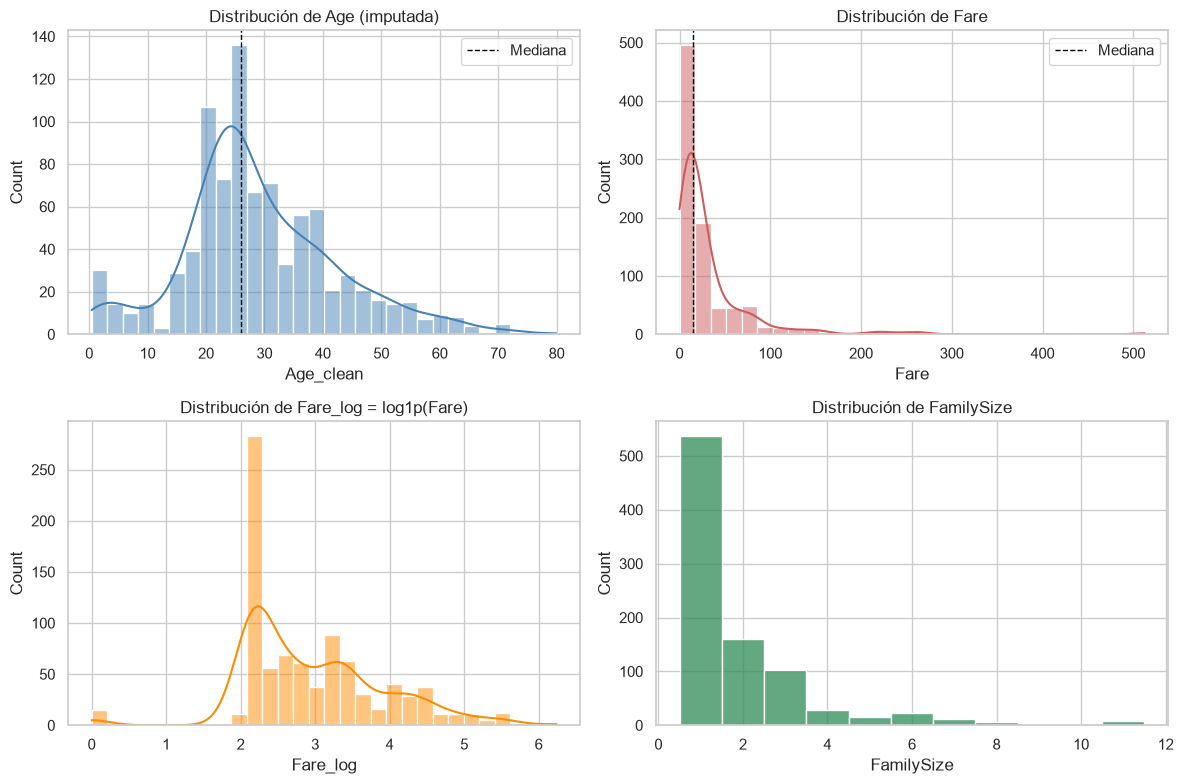

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["Age_clean"], kde=True, ax=axes[0, 0], color="steelblue", bins=30)
axes[0, 0].axvline(df["Age_clean"].median(), color="black", linestyle="--", linewidth=1, label="Mediana")
axes[0, 0].set_title("Distribución de Age (imputada)")
axes[0, 0].legend()

sns.histplot(df["Fare"], kde=True, ax=axes[0, 1], color="indianred", bins=30)
axes[0, 1].axvline(df["Fare"].median(), color="black", linestyle="--", linewidth=1, label="Mediana")
axes[0, 1].set_title("Distribución de Fare")
axes[0, 1].legend()

sns.histplot(df["Fare_log"], kde=True, ax=axes[1, 0], color="darkorange", bins=30)
axes[1, 0].set_title("Distribución de Fare_log = log1p(Fare)")

sns.histplot(df["FamilySize"], discrete=True, ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("Distribución de FamilySize")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f23_titanic_univariado_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

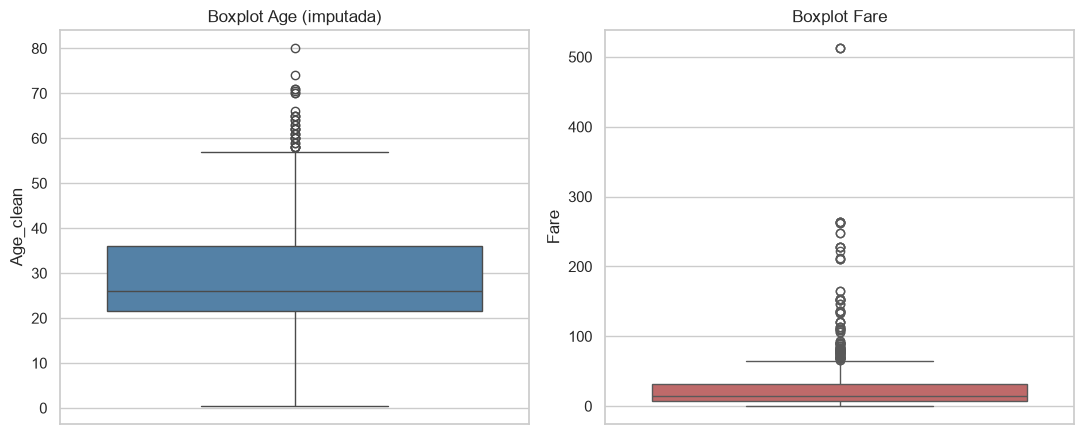

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(y=df["Age_clean"], ax=axes[0], color="steelblue")
axes[0].set_title("Boxplot Age (imputada)")
sns.boxplot(y=df["Fare"], ax=axes[1], color="indianred")
axes[1].set_title("Boxplot Fare")
plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f23_titanic_boxplots_univariados.png", dpi=150, bbox_inches="tight")
plt.show()

`Age_clean` muestra una distribución aproximadamente simétrica centrada entre 25 y 35 años, sin señales de asimetría extrema (coeficiente de asimetría cercano a 0 en la tabla anterior). `Fare` está fuertemente concentrada en valores bajos con una cola derecha extensa (algunos pasajeros con tarifas muy altas), lo que se refleja en su boxplot con múltiples puntos por sobre el bigote superior; `Fare_log` atenúa visualmente esta compresión. `FamilySize` es una variable discreta con la mayor parte de la masa en 1-2 integrantes.

In [23]:
variables_categoricas_prioritarias = ["Survived", "Pclass", "Sex", "Embarked_clean", "Title_agrupado", "AgeGroup", "Deck_combinado"]
for c in variables_categoricas_prioritarias:
    tabla = pd.concat([
        df[c].value_counts().rename("n"),
        (df[c].value_counts(normalize=True) * 100).round(1).rename("pct")
    ], axis=1)
    print(f"\nFrecuencias de {c}:")
    print(tabla)


Frecuencias de Survived:
            n   pct
Survived           
0         549  61.6
1         342  38.4

Frecuencias de Pclass:
          n   pct
Pclass           
3       491  55.1
1       216  24.2
2       184  20.7

Frecuencias de Sex:
          n   pct
Sex              
male    577  64.8
female  314  35.2

Frecuencias de Embarked_clean:
                  n   pct
Embarked_clean           
S               646  72.5
C               168  18.9
Q                77   8.6

Frecuencias de Title_agrupado:
                       n   pct
Title_agrupado                
Mr                   517  58.0
Miss                 185  20.8
Mrs                  126  14.1
Master                40   4.5
Oficial_Profesional   18   2.0
Nobleza                5   0.6

Frecuencias de AgeGroup:
                        n   pct
AgeGroup                       
Adulto joven (18-35)  540  60.6
Adulto (36-60)        216  24.2
Niño (0-12)            69   7.7
Adolescente (13-17)    44   4.9
Mayor (60+)            22  

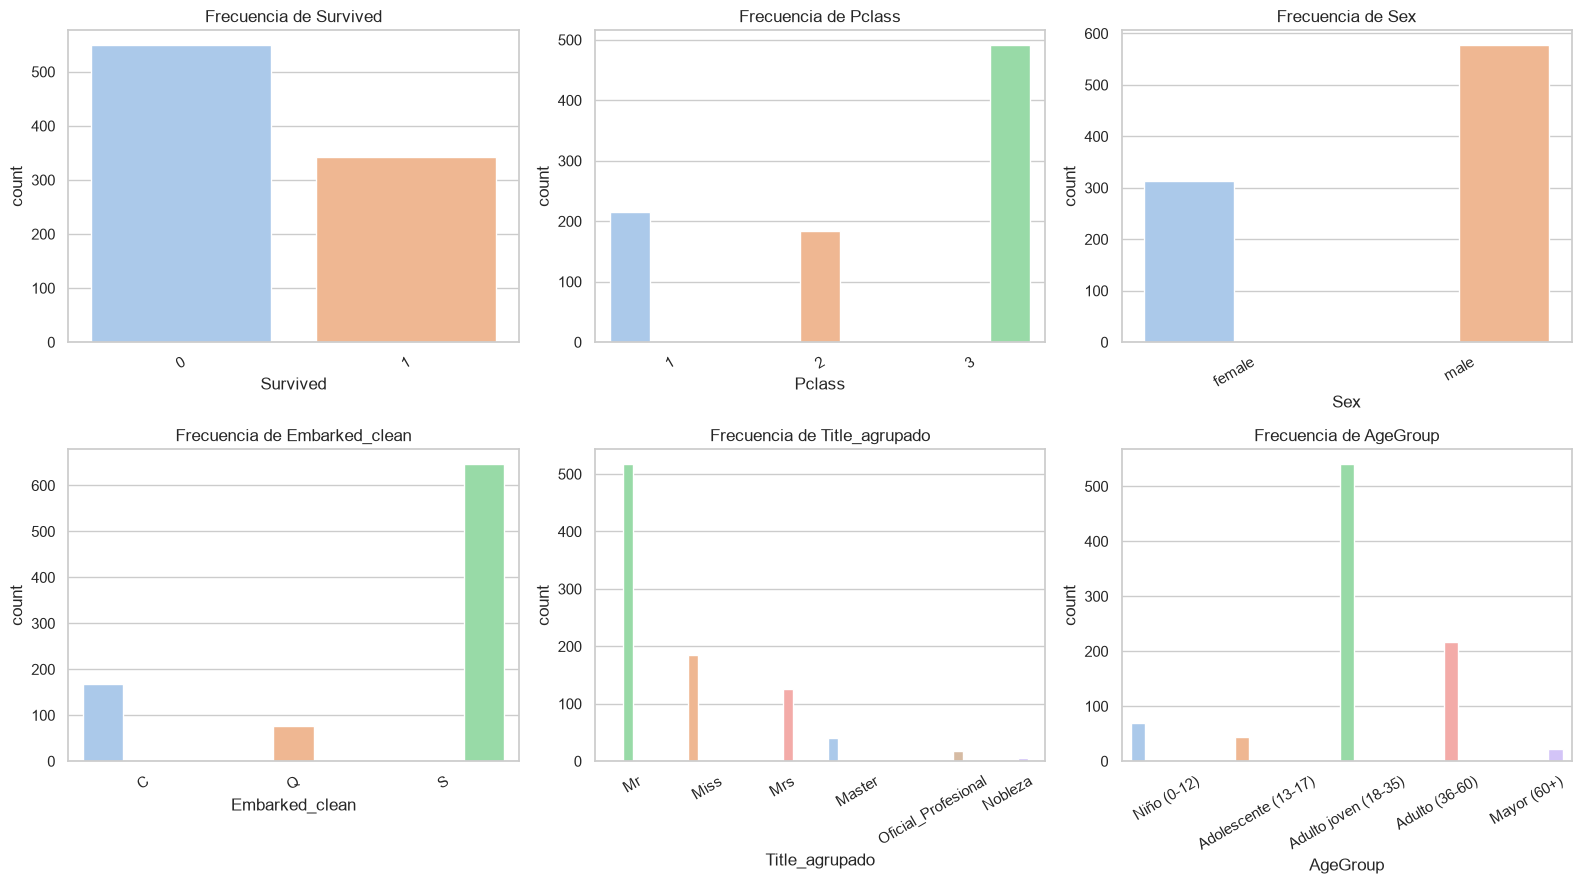

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
orden = {
    "Survived": None, "Pclass": None, "Sex": None,
    "Embarked_clean": None, "Title_agrupado": df["Title_agrupado"].value_counts().index,
    "AgeGroup": etiquetas_edad,
}
for ax, col in zip(axes.flat, orden.keys()):
    sns.countplot(data=df, x=col, hue=col, legend=False, palette="pastel", order=orden[col], ax=ax)
    ax.set_title(f"Frecuencia de {col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f23_titanic_univariado_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

**Lectura general del análisis univariado:** se confirma el desbalance ya observado en la Fase 1 (predominio de tercera clase, de hombres y de una tasa de supervivencia global minoritaria, 38.4%). El puerto de embarque está dominado por Southampton (~72%). `Title_agrupado` está dominado por `Mr` (~58%) y `Miss`/`Mrs` en conjunto (~33%), consistente con la composición de sexo/estado civil del pasaje. `AgeGroup` muestra que los adultos jóvenes (18-35) son el grupo etario mayoritario. `Deck_combinado` está dominado por la categoría `"Desconocida"` (~77%), reflejo directo del patrón de faltantes de `Cabin` diagnosticado en el apartado IV, que la integración con la fuente web no logró resolver.

---
## VIII. Análisis bivariado

Se exploran relaciones entre pares de variables, con foco en `Survived` como variable de interés central del proyecto, combinando visualizaciones apropiadas con medidas estadísticas (pruebas de asociación/diferencia y tamaños de efecto) que permiten lecturas prudentes de asociación o diferencia.

### VIII.1 Variables categóricas vs. `Survived` (chi-cuadrado de independencia y V de Cramér)

In [25]:
def prueba_chi2_cramers_v(df, col, objetivo="Survived"):
    tabla = pd.crosstab(df[col], df[objetivo])
    chi2, p, gl, esperadas = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    k = min(tabla.shape) - 1
    cramers_v = np.sqrt((chi2 / n) / k) if k > 0 else np.nan
    pct_celdas_esperadas_bajas = (esperadas < 5).mean() * 100
    return {
        "variable": col, "chi2": round(chi2, 2), "gl": gl, "p_valor": p,
        "cramers_v": round(cramers_v, 3), "pct_celdas_esperadas<5": round(pct_celdas_esperadas_bajas, 1),
    }

variables_categoricas_vs_survived = ["Sex", "Pclass", "Embarked_clean", "Title_agrupado", "AgeGroup", "IsAlone", "Deck_combinado"]
resultados_chi2 = pd.DataFrame([prueba_chi2_cramers_v(df, v) for v in variables_categoricas_vs_survived])
resultados_chi2 = resultados_chi2.sort_values("cramers_v", ascending=False).reset_index(drop=True)
resultados_chi2

,variable,chi2,gl,p_valor,cramers_v,pct_celdas_esperadas<5
0,Title_agrupado,289.84,5,1.532591e-60,0.570,16.7
1,Sex,260.72,1,1.197357e-58,0.541,0.0
2,Pclass,102.89,2,4.549252e-23,0.340,0.0
3,Deck_combinado,99.16,8,6.326020e-18,0.334,27.8
4,IsAlone,36.00,1,1.972654e-09,0.201,0.0
5,Embarked_clean,25.96,2,2.300863e-06,0.171,0.0
6,AgeGroup,16.69,4,2.217583e-03,0.137,0.0


Todas las variables categóricas evaluadas presentan una asociación estadísticamente significativa con `Survived` (p < 0.05). En magnitud de efecto (V de Cramér), `Title_agrupado` (0.57) y `Sex` (0.54) muestran la asociación más fuerte —esperable, dado que `Title_agrupado` re-codifica en gran medida sexo y edad—, seguidas de `Pclass` (0.34) y `Deck_combinado` (0.33) con asociaciones moderadas, y `IsAlone` (0.20), `Embarked_clean` (0.17) y `AgeGroup` (0.14) con asociaciones más débiles. `Title_agrupado` y, especialmente, `Deck_combinado` presentan una proporción no despreciable de celdas con frecuencia esperada menor a 5 (16.7% y 27.8% respectivamente, columna `pct_celdas_esperadas<5`) —consecuencia de categorías poco pobladas (`Nobleza`, o letras de cubierta con pocos casos)—, lo que **matiza la confiabilidad formal del p-valor** para esas dos variables y se documenta como limitación en el apartado X.

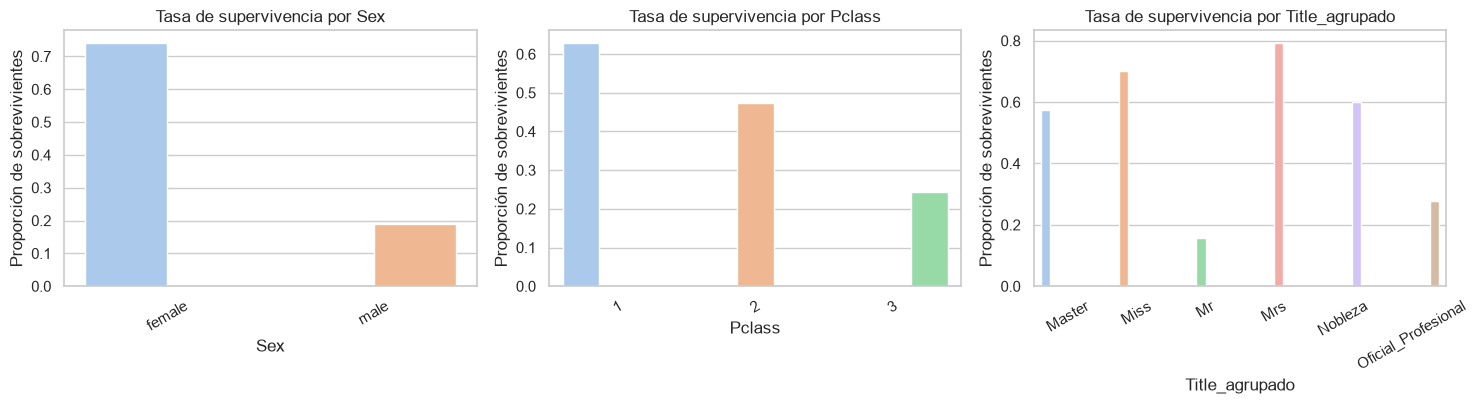

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ["Sex", "Pclass", "Title_agrupado"]):
    tasa = df.groupby(col, observed=True)["Survived"].apply(lambda s: s.astype(int).mean())
    sns.barplot(x=tasa.index, y=tasa.values, hue=tasa.index, legend=False, palette="pastel", ax=ax)
    ax.set_title(f"Tasa de supervivencia por {col}")
    ax.set_ylabel("Proporción de sobrevivientes")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f23_titanic_bivariado_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

### VIII.2 Variables numéricas vs. `Survived` (Mann-Whitney U, dado el incumplimiento de normalidad)

In [27]:
def prueba_mann_whitney(df, col, objetivo="Survived"):
    grupo0 = df.loc[df[objetivo] == 0, col].dropna()
    grupo1 = df.loc[df[objetivo] == 1, col].dropna()
    u_stat, p = stats.mannwhitneyu(grupo0, grupo1, alternative="two-sided")
    n1, n2 = len(grupo0), len(grupo1)
    correlacion_rango_biserial = 1 - (2 * u_stat) / (n1 * n2)  # tamaño de efecto no paramétrico
    return {
        "variable": col,
        "mediana_no_sobrevivio": round(grupo0.median(), 2), "mediana_sobrevivio": round(grupo1.median(), 2),
        "U": round(u_stat, 1), "p_valor": p, "r_rango_biserial": round(correlacion_rango_biserial, 3),
    }

variables_numericas_vs_survived = ["Age_clean", "Fare", "Fare_log", "FamilySize"]
resultados_mw = pd.DataFrame([prueba_mann_whitney(df, v) for v in variables_numericas_vs_survived])
resultados_mw

,variable,mediana_no_sobrevivio,mediana_sobrevivio,U,p_valor,r_rango_biserial
0,Age_clean,25.00,27.0,98171.5,2.499530e-01,-0.046
1,Fare,10.50,26.0,57806.5,4.553477e-22,0.384
2,Fare_log,2.44,3.3,57806.5,4.553477e-22,0.384
3,FamilySize,1.00,2.0,77659.0,7.970801e-07,0.173


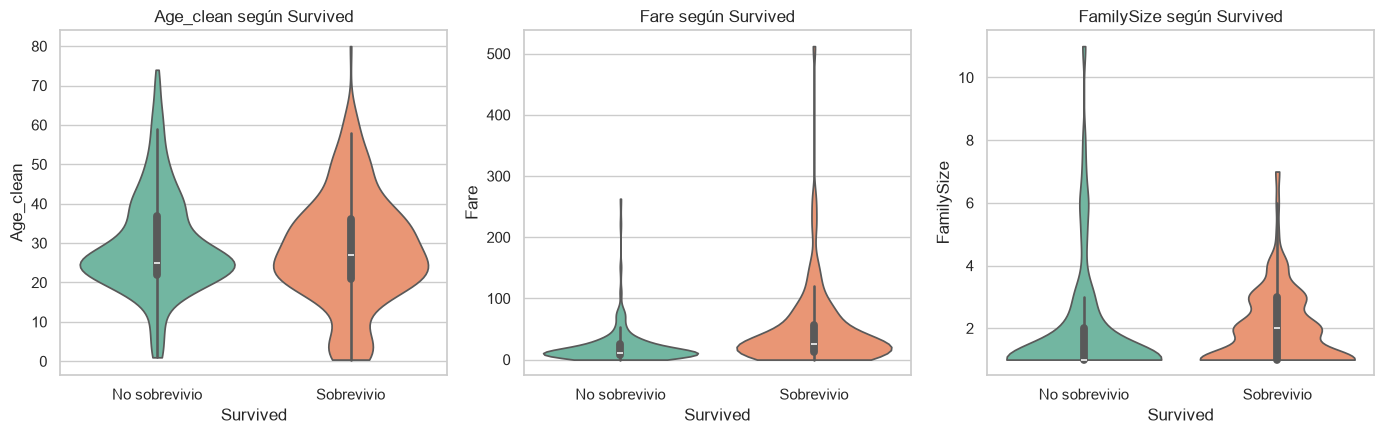

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, ["Age_clean", "Fare", "FamilySize"]):
    sns.violinplot(data=df, x="Survived", y=col, hue="Survived", legend=False, palette="Set2", ax=ax, cut=0)
    ax.set_title(f"{col} según Survived")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No sobrevivio", "Sobrevivio"])

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f23_titanic_bivariado_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

`Fare` muestra la diferencia más clara y estadísticamente significativa entre grupos (mediana de 26.0 entre quienes sobrevivieron frente a 10.5 entre quienes no, p < 0.001, tamaño de efecto moderado r ≈ 0.38), coherente con la asociación observada entre `Pclass`/`Fare` y supervivencia. `FamilySize` también difiere significativamente (mediana 2 vs. 1, p < 0.001), aunque con un tamaño de efecto menor (r ≈ 0.17), consistente con la lectura de la Fase 1 sobre `IsAlone`. `Age_clean`, en cambio, **no presenta una diferencia estadísticamente significativa** entre grupos (p ≈ 0.25) y su tamaño de efecto es prácticamente nulo (r ≈ −0.05): a diferencia de lo sugerido de forma exploratoria en la Fase 1, con esta imputación definitiva y una prueba formal no hay evidencia suficiente para afirmar que la edad, por sí sola, discrimine la supervivencia.

### VIII.3 Relaciones numérico-numéricas (Pearson y Spearman)

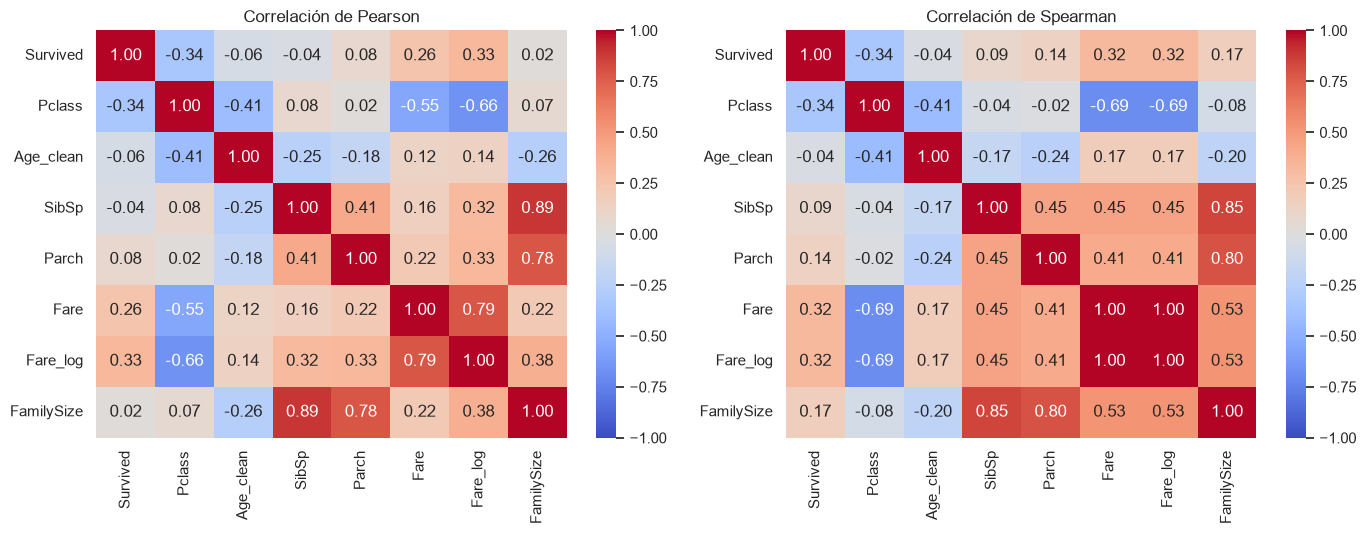

In [29]:
variables_corr = ["Survived", "Pclass", "Age_clean", "SibSp", "Parch", "Fare", "Fare_log", "FamilySize"]
df_corr = df[variables_corr].astype(float)

corr_pearson = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[0])
axes[0].set_title("Correlación de Pearson")
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
axes[1].set_title("Correlación de Spearman")

plt.tight_layout()
plt.savefig(f"{RUTA_FIGURAS}/f23_titanic_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

`Survived` correlaciona negativamente con `Pclass` y positivamente con `Fare`/`Fare_log`, en ambos coeficientes, consistente con los resultados de las secciones anteriores. La correlación de Spearman entre `Survived` y `Fare` es notoriamente más alta que la de Pearson (que es sensible a la escala y a los valores extremos de `Fare`), lo que **refuerza la decisión de reportar Spearman como medida complementaria** ante variables asimétricas. `FamilySize` mantiene correlaciones altas y esperables con `SibSp` y `Parch` (por construcción). Las correlaciones entre variables predictoras son en general moderadas o bajas, sin indicios de colinealidad extrema que amerite un tratamiento adicional en esta fase.

In [30]:
tabla_interaccion = df.groupby(["Sex", "Pclass"], observed=True)["Survived"].apply(lambda s: s.astype(int).mean()).round(3).unstack()
tabla_interaccion

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


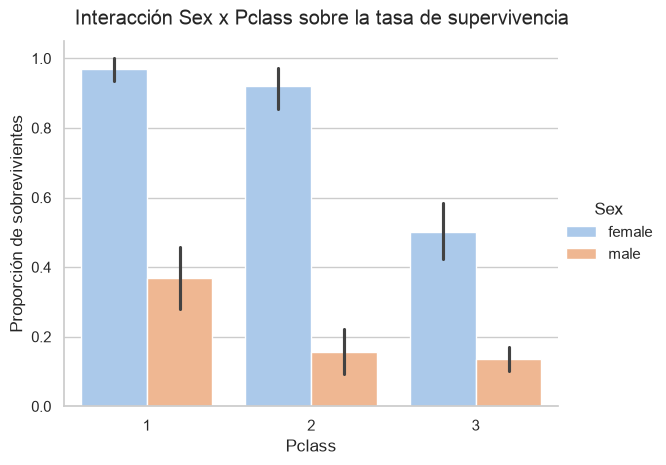

In [31]:
g = sns.catplot(data=df, x="Pclass", y="Survived", hue="Sex", kind="bar", palette="pastel", height=4.5, aspect=1.3)
g.set_axis_labels("Pclass", "Proporción de sobrevivientes")
g.fig.suptitle("Interacción Sex x Pclass sobre la tasa de supervivencia", y=1.03)
g.savefig(f"{RUTA_FIGURAS}/f23_titanic_interaccion_sexo_clase.png", dpi=150, bbox_inches="tight")
plt.show()

La tabla y el gráfico de interacción muestran que el efecto de `Pclass` sobre la supervivencia **no es uniforme entre sexos**: entre las mujeres, la tasa de supervivencia se mantiene alta incluso en tercera clase (aunque menor que en primera/segunda), mientras que entre los hombres la tasa cae de forma mucho más pronunciada al pasar de primera a tercera clase. Esta lectura matiza la heurística histórica de "mujeres y niños primero": el patrón de priorización parece haber operado de forma más consistente dentro de las clases altas que en la tercera clase.

---
## IX. Patrones, anomalías y hallazgos iniciales

Se detectan valores atípicos mediante dos métodos complementarios (IQR y Z-score robusto/MAD) y se examina evidencia adicional para distinguir, cuando es posible, entre errores de datos y comportamientos relevantes.

In [32]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (serie < li) | (serie > ls)
    return mask, {"q1": round(q1, 2), "q3": round(q3, 2), "limite_inferior": round(li, 2),
                  "limite_superior": round(ls, 2), "n_outliers": int(mask.sum()),
                  "pct_outliers": round(100 * mask.sum() / serie.notna().sum(), 2)}

def outliers_zscore_robusto(serie, umbral=3.5):
    mediana = serie.median()
    mad = stats.median_abs_deviation(serie.dropna(), scale="normal")
    z_robusto = (serie - mediana) / mad
    mask = z_robusto.abs() > umbral
    return mask, {"mediana": round(mediana, 2), "MAD": round(mad, 2),
                  "n_outliers": int(mask.sum()), "pct_outliers": round(100 * mask.sum() / serie.notna().sum(), 2)}

mask_fare_iqr, resumen_fare_iqr = outliers_iqr(df["Fare"])
mask_age_iqr, resumen_age_iqr = outliers_iqr(df["Age_clean"])
mask_fare_z, resumen_fare_z = outliers_zscore_robusto(df["Fare"])
mask_age_z, resumen_age_z = outliers_zscore_robusto(df["Age_clean"])

print("Fare - IQR:", resumen_fare_iqr)
print("Fare - Z robusto (MAD):", resumen_fare_z)
print("\nAge_clean - IQR:", resumen_age_iqr)
print("Age_clean - Z robusto (MAD):", resumen_age_z)

Fare - IQR: {'q1': 7.91, 'q3': 31.0, 'limite_inferior': -26.72, 'limite_superior': 65.63, 'n_outliers': 116, 'pct_outliers': np.float64(13.02)}
Fare - Z robusto (MAD): {'mediana': np.float64(14.45), 'MAD': np.float64(10.24), 'n_outliers': 160, 'pct_outliers': np.float64(17.96)}

Age_clean - IQR: {'q1': 21.5, 'q3': 36.0, 'limite_inferior': -0.25, 'limite_superior': 57.75, 'n_outliers': 33, 'pct_outliers': np.float64(3.7)}
Age_clean - Z robusto (MAD): {'mediana': np.float64(26.0), 'MAD': np.float64(10.38), 'n_outliers': 15, 'pct_outliers': np.float64(1.68)}


In [33]:
# ¿Los outliers de Fare son errores o boletos compartidos por grupos/familias?
outliers_fare = df.loc[mask_fare_iqr]
print("Pclass de los outliers de Fare (IQR):")
print(outliers_fare["Pclass"].value_counts())
print(f"\n% de outliers de Fare cuyo Ticket es compartido con otro pasajero: "
      f"{(outliers_fare['Ticket'].isin(titanic['Ticket'][titanic['Ticket'].duplicated(keep=False)])).mean() * 100:.1f}%")

# Casos con Fare == 0: ¿siguen un patron identificable (p. ej., mismo prefijo de Ticket)?
casos_fare_cero = df.loc[df["Fare"] == 0, ["PassengerId", "Pclass", "Sex", "Title_agrupado", "Ticket", "Embarked_clean"]]
casos_fare_cero

Pclass de los outliers de Fare (IQR):
Pclass
1    104
3      7
2      5
Name: count, dtype: int64

% de outliers de Fare cuyo Ticket es compartido con otro pasajero: 92.2%


,PassengerId,Pclass,Sex,Title_agrupado,Ticket,Embarked_clean
179,180,3,male,Mr,LINE,S
263,264,1,male,Mr,112059,S
271,272,3,male,Mr,LINE,S
277,278,2,male,Mr,239853,S
302,303,3,male,Mr,LINE,S
413,414,2,male,Mr,239853,S
466,467,2,male,Mr,239853,S
481,482,2,male,Mr,239854,S
597,598,3,male,Mr,LINE,S
633,634,1,male,Mr,112052,S


**Distinción entre error de dato y comportamiento relevante:**

- Los outliers de `Fare` (método IQR) se concentran casi en su totalidad en primera clase y, en su mayoría, corresponden a boletos (`Ticket`) compartidos con otros pasajeros del dataset, lo que es consistente con la práctica histórica de comprar un único pasaje para un grupo familiar (la tarifa registrada sería la del grupo completo, no la individual). Esto respalda tratarlos como **valores válidos y relevantes**, no como errores de captura, y se documentan como candidatos a un tratamiento específico (p. ej., tarifa por persona) en una fase de modelado posterior.
- Los outliers de `Age_clean` son escasos y se concentran en edades avanzadas (adultos mayores), un comportamiento demográficamente plausible en un trasatlántico de la época, por lo que tampoco se interpretan como errores.
- Los 15 casos con `Fare == 0` (detectados en el diagnóstico de calidad) son, sin excepción, hombres embarcados en Southampton, con título `Mr` en 14 de los 15 casos, y se distribuyen entre las tres clases de pasaje (5 en primera, 6 en segunda, 4 en tercera); varios comparten el mismo número de `Ticket` entre sí (p. ej., cuatro casos con `Ticket = "LINE"` y otros con boletos correlativos). Sin un campo de rol/tripulación disponible en el dataset no es posible confirmarlo de forma concluyente dentro de este análisis, por lo que este hallazgo se registra como **hipótesis razonable, no como conclusión cerrada**: el patrón (solo hombres, boletos compartidos o atípicos, tarifa nula) es consistente con lo documentado en la literatura histórica del hundimiento sobre empleados de la naviera que viajaban registrados como pasajeros.
- El método robusto basado en MAD detecta una proporción de outliers de `Fare` similar (algo mayor) a la de IQR, lo que refuerza que la señal no es artefacto del método elegido; para `Age_clean` ambos métodos coinciden en una proporción baja de casos atípicos.

**Patrones relevantes identificados en esta fase:**

- La supervivencia está fuertemente estructurada por `Sex` y `Pclass`, y su interacción (apartado VIII.3) matiza la heurística histórica "mujeres y niños primero": el patrón beneficia de forma más marcada a las mujeres de clases altas.
- `Fare`/`Fare_log` es, entre las variables numéricas, la que más discrimina supervivencia, coherente con su rol como proxy de `Pclass`.
- La práctica de compra de boletos grupales (mismo `Ticket`) explica una parte relevante de los valores atípicos de `Fare`, un hallazgo que solo emergió al combinar el diagnóstico de duplicados de `Ticket` (apartado IV) con la detección de outliers.
- La ausencia de `Cabin`/`deck` es estructural (asociada a `Pclass`), no aleatoria, y no pudo resolverse ni siquiera integrando una segunda fuente independiente, lo que es en sí mismo un hallazgo relevante sobre los límites del dataset.

---
## X. Supuestos, límites y cierre del avance

### Resumen del estado final del avance

El dataset fue diagnosticado, limpiado (imputación definitiva de `Embarked` y `Age`, con `Cabin` tratada mediante indicador en lugar de imputación directa), integrado con una fuente complementaria de origen web (validada estructural y semánticamente) y transformado (variables derivadas de fecha/categoría, transformación logarítmica de `Fare`, tipado categórico). Sobre esa base se desarrolló un análisis exploratorio univariado y bivariado con pruebas estadísticas formales (normalidad, chi-cuadrado con V de Cramér, Mann-Whitney U, correlaciones de Pearson y Spearman) y una identificación inicial de outliers con dos métodos complementarios.

### Supuestos considerados

- Se asume que `PassengerId` identifica de forma única a cada pasajero y que no existen duplicados relevantes (verificado en el apartado IV).
- Se asume que la fuente complementaria (`seaborn`-data) y la fuente principal están alineadas fila a fila en el mismo orden; este supuesto se **validó empíricamente** (coincidencia del 100% en siete variables compartidas, apartado V) pero sigue siendo, en sentido estricto, un supuesto de integración por posición y no por llave explícita.
- Se asume que la imputación de `Age` mediante la mediana por `Pclass x Sex` es una aproximación razonable dada la evidencia de diferencias significativas entre esos grupos (Kruskal-Wallis, apartado V), aunque no reproduce la variabilidad real de cada individuo.
- Se asume que la ausencia de `Cabin`/`deck` está mayoritariamente asociada a `Pclass` (missing no completamente al azar), con base en la evidencia cruzada del apartado IV, sin poder descartar formalmente otros mecanismos.

### Limitaciones detectadas

- La integración con la fuente web no aporta información nueva sobre `Cabin`/`deck` más allá de la ya disponible (ambas fuentes comparten el mismo patrón de faltantes en ese campo), por lo que su principal aporte en esta fase es de validación cruzada y de variables complementarias (`class`, `embark_town`, `who`, `alone`), no de completitud.
- Algunas pruebas chi-cuadrado (en particular para `AgeGroup`) presentan una proporción de celdas con frecuencia esperada menor a 5, lo que reduce la confiabilidad formal del p-valor asociado; el resultado se reporta igualmente por transparencia, pero se interpreta con cautela.
- La imputación de `Age` y el indicador `Cabin_registrada`, si se usan en una fase de modelado predictivo posterior, introducen un riesgo de fuga de información (*leakage*) si no se recalculan exclusivamente sobre el conjunto de entrenamiento; se deja como advertencia explícita para esa etapa.
- El análisis es descriptivo y exploratorio: las asociaciones documentadas (incluida la interacción `Sex x Pclass`) no deben leerse como relaciones causales.

### Observaciones finales

El avance cumple con evidenciar, de forma trazable y reproducible, el ciclo diagnóstico → limpieza → integración → transformación → análisis exploratorio exigido para las Fases 2 y 3, dejando una base de datos preparada (`titanic_prepared.csv`) y una síntesis de hallazgos que sustentan decisiones de modelado futuras.

---
## XI. Cierre del avance

### Síntesis breve del trabajo realizado

En este avance se diagnosticó formalmente la calidad del dataset Titanic (valores faltantes, duplicados, inconsistencias y campos críticos), se aplicaron decisiones de limpieza definitivas (imputación de `Embarked` y `Age`, indicadores de `Cabin`), se integró una fuente complementaria de origen web tras validar su correspondencia estructural y semántica, se generaron transformaciones analíticas (variables derivadas, tipado, transformación logarítmica) y se desarrolló un análisis exploratorio univariado y bivariado sustentado en pruebas estadísticas (normalidad, chi-cuadrado y V de Cramér, Mann-Whitney U, correlaciones de Pearson y Spearman), incluyendo la detección y contextualización de valores atípicos.

### Principales hallazgos de la fase

- `Sex`, `Pclass` y `Fare` (y sus derivados `Title_agrupado`, `Fare_log`) son las variables con mayor asociación con `Survived`, todas estadísticamente significativas y con tamaños de efecto moderados a fuertes.
- La interacción `Sex x Pclass` matiza el patrón histórico de evacuación: el beneficio de ser mujer en la supervivencia es más marcado en clases altas que en tercera clase.
- Los principales valores atípicos de `Fare` corresponden mayoritariamente a boletos grupales de primera clase (no a errores de captura), mientras que la ausencia de `Cabin`/`deck` es un patrón estructural asociado a `Pclass` que ninguna de las dos fuentes disponibles logra resolver.
- El dataset queda preparado (`data/titanic_prepared.csv`) con variables imputadas, indicadores de "missingness" preservados y variables derivadas listas para su uso analítico posterior.

### Proyección para las siguientes etapas del proyecto

Las fases posteriores deberán abordar: (a) la codificación final de variables categóricas (p. ej., *one-hot encoding*) orientada a modelado, evitando fuga de información al recalcular imputaciones solo sobre el conjunto de entrenamiento; (b) la partición de los datos en conjuntos de entrenamiento y prueba; (c) la selección, implementación y evaluación de modelos predictivos de clasificación orientados a estimar la probabilidad de supervivencia, y (d) la validación de los hallazgos exploratorios documentados en este avance (en particular, la interacción `Sex x Pclass`) como posibles variables de interacción en el modelado.